# birddog walkthrough

**A leash for AI scraping agents.** One Python context manager wraps an agent that hits the web and adds:

1. Domain allowlist with wildcard subdomains
2. Per-domain rate caps (token bucket)
3. JSONL audit log, one line per fetch
4. Optional Bright Data Web Unlocker proxy routing
5. Bundled Streamlit dashboard

This notebook is the guided tour for the **Bright Data Web Data UNLOCKED** hackathon (lablab.ai, May 25 to 31, 2026).

Everything below runs offline using `httpx.MockTransport` so reviewers can rerun without a live Bright Data account or any network egress.

Repo: <https://github.com/MukundaKatta/birddog>

## Setup

Install with `pip install -e ".[notebook]"` from the repo root. Then import `Birddog` and the two error classes we will demonstrate.

In [1]:
import json
import os
import shutil
from pathlib import Path

import httpx
import matplotlib.pyplot as plt
import pandas as pd

from birddog import Birddog, DomainDeniedError, RateLimitedError
from birddog import birddog as _bd_mod

AUDIT_PATH = "runs/walkthrough.jsonl"

# Fresh audit log for the walkthrough so the cells below are reproducible.
Path("runs").mkdir(exist_ok=True)
if Path(AUDIT_PATH).exists():
    Path(AUDIT_PATH).unlink()

print("birddog imports OK, audit log:", AUDIT_PATH)

birddog imports OK, audit log: runs/walkthrough.jsonl


## Offline transport

The cells below use `httpx.MockTransport` to fake responses for two hosts:

- `docs.brightdata.com` returns a tiny HTML page
- `shop.example.com` returns a JSON product blob

Everything else returns 404. We patch `birddog._SessionCM.__enter__` so the bundled httpx client is swapped for one driven by the mock transport. This is the same pattern `examples/scrape_demo.py` uses.

In [2]:
def _fake_handler(request: httpx.Request) -> httpx.Response:
    host = request.url.host
    path = request.url.path
    if host == "docs.brightdata.com":
        return httpx.Response(200, html=f"<html><h1>docs ({path})</h1></html>")
    if host == "shop.example.com":
        return httpx.Response(200, json={"url": str(request.url), "price": 9.99})
    return httpx.Response(404, text="not found")


_original_enter = _bd_mod._SessionCM.__enter__


def _patched_enter(self):
    session = _original_enter(self)
    session._http.close()
    session._http = httpx.Client(
        transport=httpx.MockTransport(_fake_handler),
        follow_redirects=True,
    )
    return session


_bd_mod._SessionCM.__enter__ = _patched_enter
print("MockTransport wired in.")

MockTransport wired in.


## Cell 1 - Bare birddog: allowlist + rate cap, no Bright Data

Two allowed hosts. QPS cap of 1 per host with a burst of 2. No Bright Data config, so this runs as a plain local rate-limited fetcher with audit.

In [3]:
bd = Birddog(
    allowed_domains={"docs.brightdata.com", "*.example.com"},
    per_domain_qps=1.0,
    per_domain_burst=2.0,
    audit_path=AUDIT_PATH,
)

with bd.session("walkthrough") as s:
    r = s.fetch("https://docs.brightdata.com/api")
    print(f"fetch ok: status={r.status} bytes={r.bytes_len} ms={r.elapsed_ms} via_brightdata={r.via_brightdata}")
    r = s.fetch("https://shop.example.com/p/widget-a")
    print(f"fetch ok: status={r.status} bytes={r.bytes_len} ms={r.elapsed_ms}")
    print(f"summary: fetches_ok={s.fetches_ok} bytes={s.bytes_total}")

fetch ok: status=200 bytes=33 ms=0.36 via_brightdata=False
fetch ok: status=200 bytes=58 ms=0.12
summary: fetches_ok=2 bytes=91


## Cell 2 - Trigger `DomainDeniedError` on purpose

Hit a host that is not on the allowlist. birddog raises before the request fires and writes a `domain_denied` line to the audit log.

In [4]:
with bd.session("deny-demo") as s:
    try:
        s.fetch("https://evil.attacker.example/exfil")
    except DomainDeniedError as e:
        print(f"caught DomainDeniedError: {e}")

# Show the matching audit log line.
lines = Path(AUDIT_PATH).read_text().splitlines()
deny_line = next(l for l in reversed(lines) if json.loads(l)["kind"] == "domain_denied")
print("audit:", json.dumps(json.loads(deny_line), indent=2))

caught DomainDeniedError: host 'evil.attacker.example' not in allowlist
audit: {
  "ts": 1779641717.754445,
  "session_id": "deny-demo",
  "kind": "domain_denied",
  "url": "https://evil.attacker.example/exfil",
  "host": "evil.attacker.example",
  "status": null,
  "bytes": 0,
  "elapsed_ms": 0.0,
  "error": "host 'evil.attacker.example' not in allowlist",
  "extra": {}
}


## Cell 3 - Trigger `RateLimitedError` on purpose

Burst four hits in a row on `shop.example.com`. Burst capacity is 2 and the bucket refills at 1 qps, so the third fetch is denied immediately.

In [5]:
with bd.session("burst-demo") as s:
    for i in range(4):
        try:
            r = s.fetch(f"https://shop.example.com/products/{i}")
            print(f"[{i}] ok status={r.status}")
        except RateLimitedError as e:
            print(f"[{i}] rate_limited: {e}")

lines = Path(AUDIT_PATH).read_text().splitlines()
rate_line = next(l for l in reversed(lines) if json.loads(l)["kind"] == "rate_limited")
print("audit:", json.dumps(json.loads(rate_line), indent=2))

[0] ok status=200
[1] ok status=200
[2] rate_limited: per-domain QPS cap reached for 'shop.example.com'
[3] rate_limited: per-domain QPS cap reached for 'shop.example.com'
audit: {
  "ts": 1779641717.762969,
  "session_id": "burst-demo",
  "kind": "rate_limited",
  "url": "https://shop.example.com/products/3",
  "host": "shop.example.com",
  "status": null,
  "bytes": 0,
  "elapsed_ms": 0.0,
  "error": "per-domain QPS cap reached for 'shop.example.com'",
  "extra": {}
}


## Cell 4 - Load the audit log into a DataFrame

The JSONL log is dashboard-ready out of the box. Load it into pandas and aggregate fetches per host plus p50 latency.

In [6]:
rows = [json.loads(line) for line in Path(AUDIT_PATH).read_text().splitlines() if line.strip()]
df = pd.DataFrame(rows)
print(f"events: {len(df)}, kinds: {sorted(df['kind'].unique())}")

by_host = (
    df[df["kind"] == "fetch_ok"]
    .groupby("host")
    .agg(fetches=("url", "count"), bytes=("bytes", "sum"), p50_ms=("elapsed_ms", "median"))
    .sort_values("fetches", ascending=False)
)
by_host

events: 13, kinds: ['domain_denied', 'fetch_ok', 'rate_limited', 'session_close', 'session_open']


,fetches,bytes,p50_ms
host,,,
shop.example.com,3,174,0.12
docs.brightdata.com,1,33,0.36


## Cell 5 - Matplotlib bar chart of fetches per host

Same data, a quick visual.

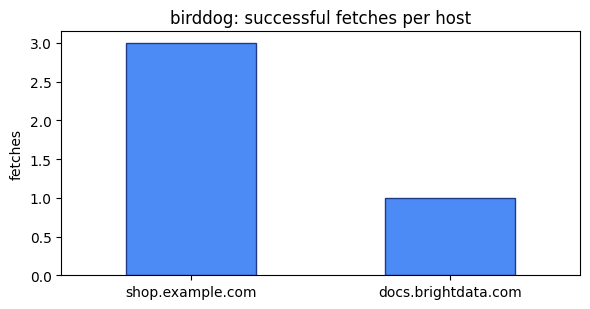

In [7]:
fig, ax = plt.subplots(figsize=(6, 3.2))
by_host["fetches"].plot.bar(ax=ax, color="#4c8bf5", edgecolor="#1f3a8a")
ax.set_title("birddog: successful fetches per host")
ax.set_ylabel("fetches")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Cell 6 - Optional: Bright Data Web Unlocker wiring

When you want the same code to route through Bright Data, pass a `bright_data` dict to `Birddog(...)`. birddog will configure the underlying httpx client to use the Web Unlocker as an HTTP proxy and stamp `via_brightdata=True` on every `FetchResult` so downstream tooling can prove which traffic went through the Unlocker.

The cell below is commented out so the notebook stays offline. To enable, export the standard env vars and uncomment.

```
export BRIGHTDATA_HOST="brd.superproxy.io:33335"
export BRIGHTDATA_USERNAME="brd-customer-XXXXXX-zone-web_unlocker"
export BRIGHTDATA_PASSWORD="..."
```

In [8]:
# Restore the real httpx client behavior for any later real-network runs.
_bd_mod._SessionCM.__enter__ = _original_enter

# bright_data_config = {
#     "host": os.environ["BRIGHTDATA_HOST"],
#     "username": os.environ["BRIGHTDATA_USERNAME"],
#     "password": os.environ["BRIGHTDATA_PASSWORD"],
# }
#
# bd_live = Birddog(
#     allowed_domains={"example.com", "*.example.com"},
#     per_domain_qps=0.5,
#     audit_path="runs/live.jsonl",
#     bright_data=bright_data_config,
# )
#
# with bd_live.session("live-demo") as s:
#     r = s.fetch("https://example.com/")
#     assert r.via_brightdata is True
#     print("fetched", r.status, "bytes", r.bytes_len, "via_brightdata", r.via_brightdata)

print("shape of the Bright Data config dict:")
print({"host": "<proxy host:port>", "username": "<zone username>", "password": "<zone password>"})

shape of the Bright Data config dict:
{'host': '<proxy host:port>', 'username': '<zone username>', 'password': '<zone password>'}


## What now

- Full feature walkthrough: [README](https://github.com/MukundaKatta/birddog#readme)
- Realistic agent example: `examples/watchdog_agent.py` (price tracker, 3 passes with denial + rate cap + threshold alerts)
- Streamlit dashboard for any audit log:

  ```
  streamlit run -m birddog.dashboard -- --audit runs/walkthrough.jsonl
  ```

- Companion libraries in the same agent-stack: [agentleash](https://github.com/MukundaKatta/agentleash), [agentvet](https://github.com/MukundaKatta/agentvet), [agentsnap](https://github.com/MukundaKatta/agentsnap), [agenttrace](https://github.com/MukundaKatta/agenttrace).

Hackathon submission draft: `docs/HACKATHON_SUBMISSION.md`.